# Insider Threat Behavioral Intelligence System

## Exploratory Data Analysis (EDA)

### Objective

This notebook performs Exploratory Data Analysis (EDA) on the engineered feature dataset (`final_features.csv`). It verifies data quality, explores feature distributions, analyzes user behavior patterns, and prepares the dataset for anomaly detection model training.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
DATA_PATH = PROJECT_ROOT / "datasets" / "processed" / "final_features.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(265, 11)


,user,device_connections,emails_sent,files_accessed,websites_visited,logon_count,O,C,E,A,N
0,LRR0148,1569,0,907,57200,1378,21,19,14,14,29
1,HAH0760,1342,150,1900,10034,957,34,17,22,37,30
2,BIS0247,232,413,418,31140,1056,36,19,18,39,37
3,MAR0955,42,0,69,2963,604,36,44,23,44,25
4,OCS0865,1310,725,873,56052,1005,29,24,43,35,32


## Dataset Information

This section displays the dataset dimensions, column names, data types, and general information before performing detailed analysis.

In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(265, 11)

Columns:
['user', 'device_connections', 'emails_sent', 'files_accessed', 'websites_visited', 'logon_count', 'O', 'C', 'E', 'A', 'N']

Data Types:
user                    str
device_connections    int64
emails_sent           int64
files_accessed        int64
websites_visited      int64
logon_count           int64
O                     int64
C                     int64
E                     int64
A                     int64
N                     int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   user                265 non-null    str  
 1   device_connections  265 non-null    int64
 2   emails_sent         265 non-null    int64
 3   files_accessed      265 non-null    int64
 4   websites_visited    265 non-null    int64
 5   logon_count         265 non-null    int64
 6   O        

## Missing Value Analysis

This section checks whether the engineered feature dataset contains any missing (null) values before model training.

In [3]:
print("Missing Values in Each Column")

missing = df.isnull().sum()

print(missing)

Missing Values in Each Column
user                  0
device_connections    0
emails_sent           0
files_accessed        0
websites_visited      0
logon_count           0
O                     0
C                     0
E                     0
A                     0
N                     0
dtype: int64


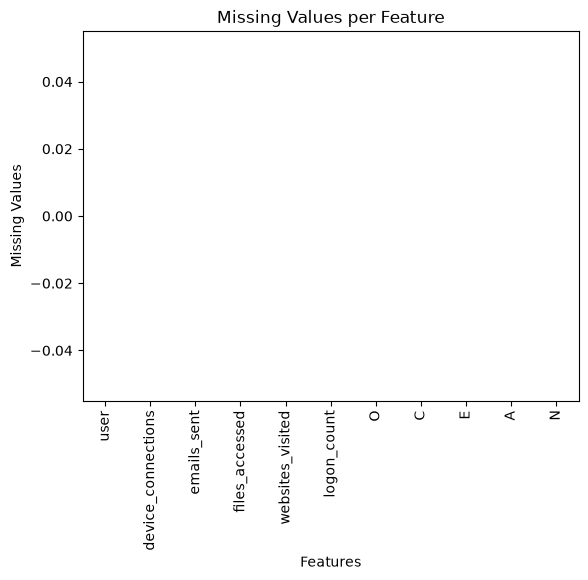

In [4]:
import matplotlib.pyplot as plt

missing.plot(kind="bar")

plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Missing Values")

plt.show()

## Statistical Summary

This section provides descriptive statistics of the engineered features. It summarizes the distribution of each feature including count, mean, standard deviation, minimum, maximum and quartile values.

In [5]:
print("Statistical Summary")

df.describe()

Statistical Summary


,device_connections,emails_sent,files_accessed,websites_visited,logon_count,O,C,E,A,N
count,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000
mean,1529.735849,318.977358,1681.437736,28270.600000,966.815094,33.966038,31.539623,28.271698,29.709434,29.830189
std,2010.040430,544.764078,2449.847159,19862.616879,491.008108,10.437167,11.697551,11.132541,11.381575,4.826285
min,4.000000,0.000000,0.000000,350.000000,73.000000,10.000000,10.000000,10.000000,10.000000,18.000000
25%,271.000000,0.000000,337.000000,10034.000000,662.000000,24.000000,20.000000,19.000000,20.000000,27.000000
50%,779.000000,74.000000,641.000000,31140.000000,972.000000,37.000000,36.000000,26.000000,30.000000,30.000000
75%,1420.000000,433.000000,1845.000000,40850.000000,1161.000000,42.000000,41.000000,38.000000,40.000000,33.000000
max,8502.000000,4111.000000,11627.000000,98610.000000,3267.000000,50.000000,50.000000,50.000000,50.000000,42.000000


## Feature Distribution

This section visualizes the distribution of important behavioral features to understand employee activity patterns.

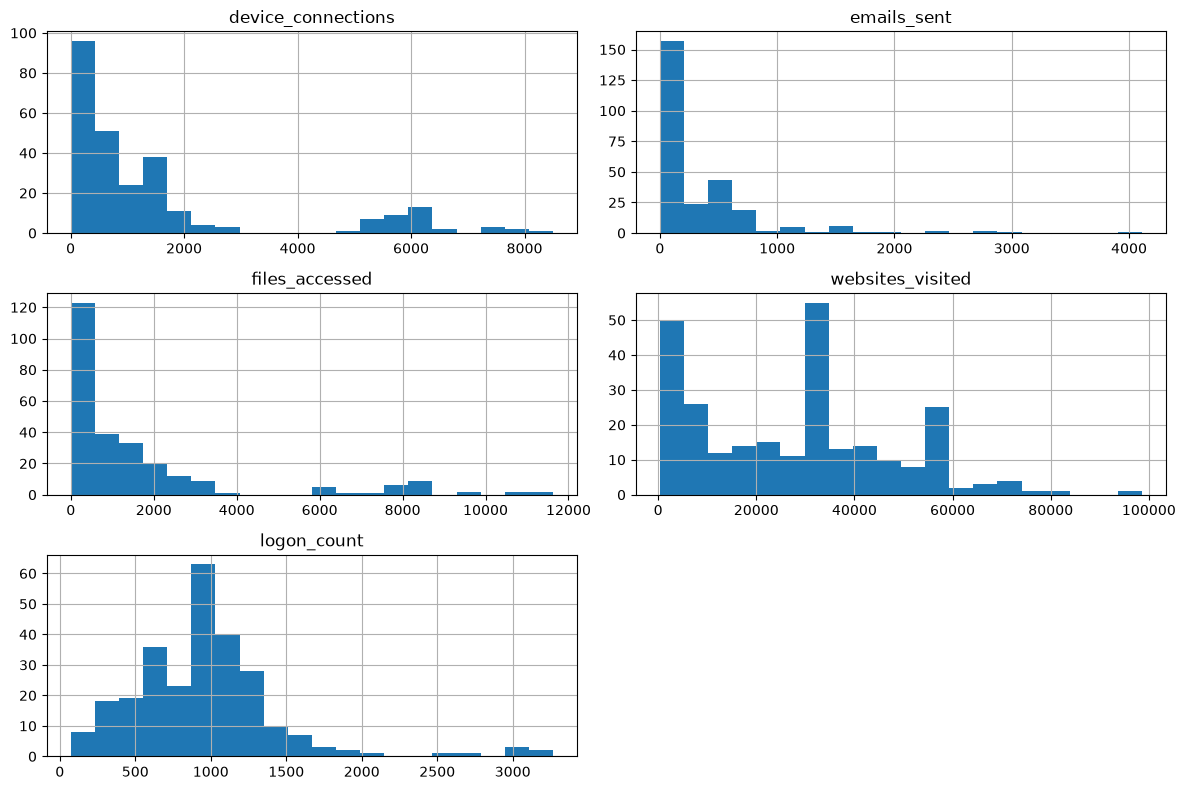

In [6]:
import matplotlib.pyplot as plt

numeric_columns = [
    "device_connections",
    "emails_sent",
    "files_accessed",
    "websites_visited",
    "logon_count"
]

df[numeric_columns].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

## Correlation Analysis

This section computes the correlation matrix of the numerical features and visualizes it using a heatmap. It helps identify relationships between different user behavioral features before training the anomaly detection model.

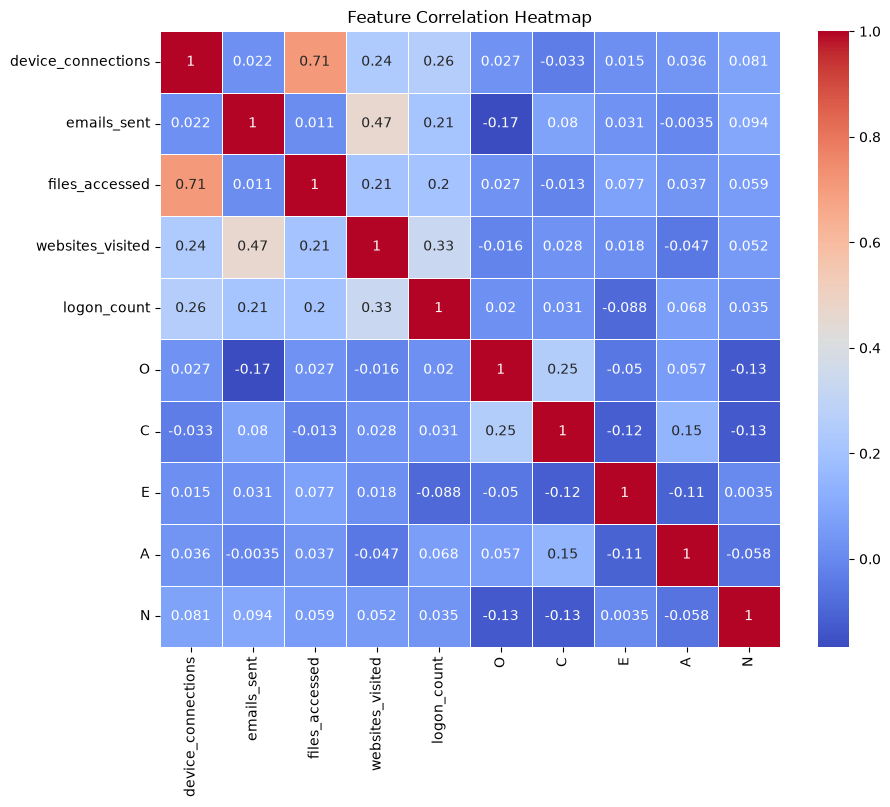

In [7]:
plt.figure(figsize=(10, 8))

correlation = df.drop(columns=["user"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Outlier Analysis

This section visualizes the distribution of numerical features using box plots. It helps identify outliers and unusual user behavior before training the anomaly detection model.

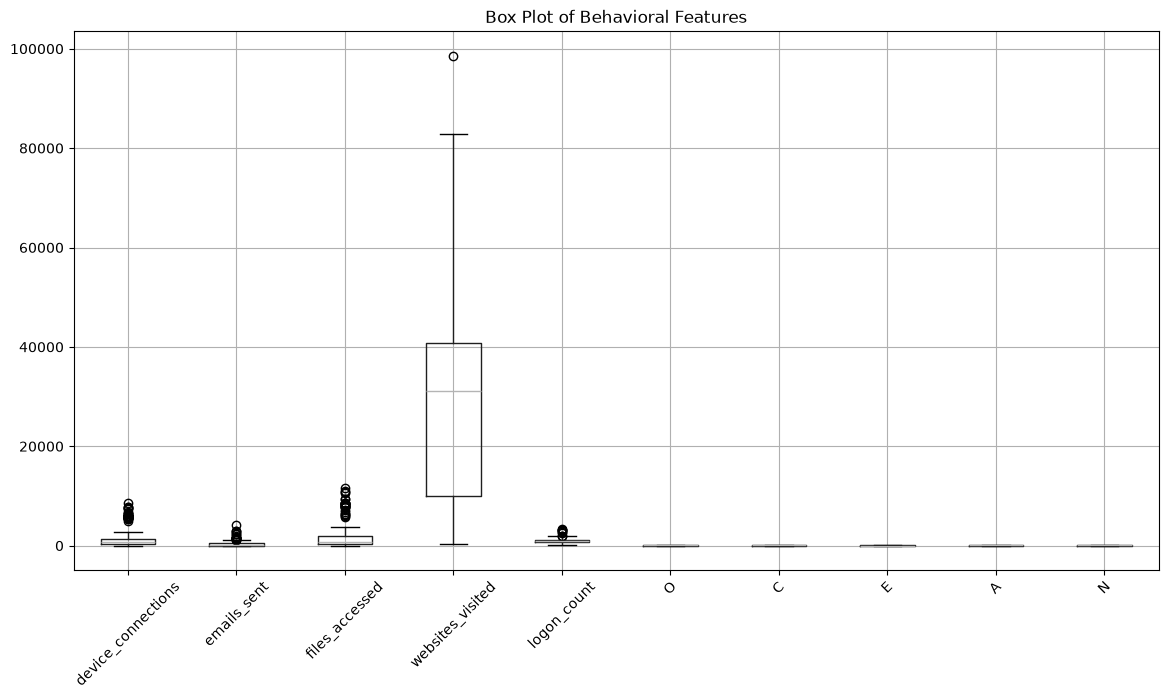

In [8]:
plt.figure(figsize=(14,7))

df.drop(columns=["user"]).boxplot()

plt.title("Box Plot of Behavioral Features")

plt.xticks(rotation=45)

plt.show()